# Random Forest

#### Imports

In [20]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

from src.rf_experiment import RandomForestExperiment
from src.utils import evaluate_model, save_results

## Experimento 1: Conjunto com todas as Features

In [21]:
import pandas as pd
caminho = '../'

X_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### RF - Default

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_exp1 = RandomForestClassifier(n_estimators=100, random_state=14)
rf_exp1.fit(X_train_exp1, y_train_exp1)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


=== Métricas rf_def_exp1  ===
    Acurácia: 0.7928
    Precisão: 0.7751
    Recall:   0.7311
    F1-Score: 0.7451
    MCC:      0.5043
    AUC:      0.8469


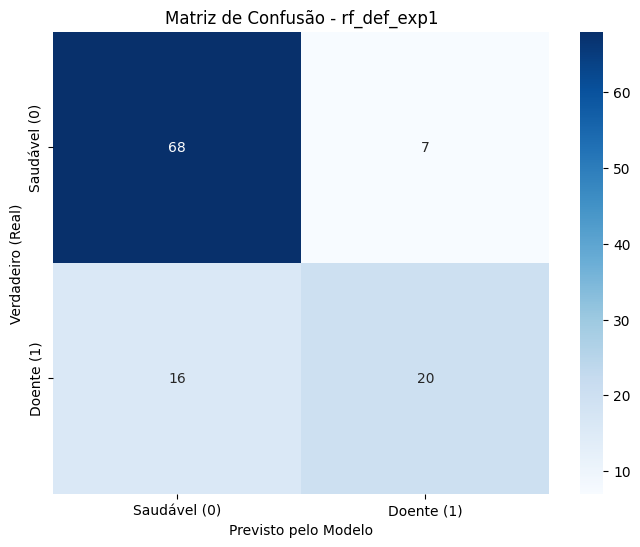

In [23]:
# Avaliar modelo
y_pred_def_exp1 = rf_exp1.predict(X_test_exp1)
y_prob_def_exp1 = rf_exp1.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_def_exp1, y_prob_def_exp1, 'rf_def_exp1')
save_results(y_pred_def_exp1, y_prob_def_exp1, 'rf_def_exp1', caminho)

### RF - Melhorado

In [24]:
# Criar o experimento
experimento_1 = RandomForestExperiment(X_train_exp1, y_train_exp1, 'rf_otz_exp1', caminho)
experimento_1.tune_and_fit(n_trials=50)
best_rf = experimento_1.best_model

[I 2026-08-16 15:06:38,887] A new study created in memory with name: no-name-13f60500-d403-4143-89e1-fe7e0789329c


Iniciando otimização do cenário rf_otz_exp1.


Best trial: 0. Best value: 0.798643:   2%|▏         | 1/50 [00:05<04:47,  5.86s/it]

[I 2026-08-16 15:06:44,742] Trial 0 finished with value: 0.7986425339366515 and parameters: {'n_estimators': 282, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 0 with value: 0.7986425339366515.


Best trial: 1. Best value: 0.814103:   4%|▍         | 2/50 [00:10<04:15,  5.32s/it]

[I 2026-08-16 15:06:49,686] Trial 1 finished with value: 0.8141025641025641 and parameters: {'n_estimators': 91, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 1 with value: 0.8141025641025641.


Best trial: 1. Best value: 0.814103:   6%|▌         | 3/50 [00:13<03:15,  4.17s/it]

[I 2026-08-16 15:06:52,486] Trial 2 finished with value: 0.7868778280542987 and parameters: {'n_estimators': 145, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 1 with value: 0.8141025641025641.


Best trial: 1. Best value: 0.814103:   8%|▊         | 4/50 [00:13<02:01,  2.64s/it]

[I 2026-08-16 15:06:52,777] Trial 3 finished with value: 0.7907993966817495 and parameters: {'n_estimators': 143, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 1 with value: 0.8141025641025641.


Best trial: 1. Best value: 0.814103:  10%|█         | 5/50 [00:14<01:18,  1.75s/it]

[I 2026-08-16 15:06:52,952] Trial 4 finished with value: 0.7947209653092004 and parameters: {'n_estimators': 91, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 1 with value: 0.8141025641025641.


Best trial: 1. Best value: 0.814103:  12%|█▏        | 6/50 [00:14<00:56,  1.28s/it]

[I 2026-08-16 15:06:53,335] Trial 5 finished with value: 0.7987179487179487 and parameters: {'n_estimators': 184, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 1 with value: 0.8141025641025641.


Best trial: 1. Best value: 0.814103:  14%|█▍        | 7/50 [00:14<00:40,  1.05it/s]

[I 2026-08-16 15:06:53,607] Trial 6 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 131, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 1 with value: 0.8141025641025641.


Best trial: 1. Best value: 0.814103:  16%|█▌        | 8/50 [00:15<00:33,  1.25it/s]

[I 2026-08-16 15:06:54,073] Trial 7 finished with value: 0.7947963800904977 and parameters: {'n_estimators': 245, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 1 with value: 0.8141025641025641.


Best trial: 1. Best value: 0.814103:  18%|█▊        | 9/50 [00:15<00:27,  1.51it/s]

[I 2026-08-16 15:06:54,433] Trial 8 finished with value: 0.7986425339366515 and parameters: {'n_estimators': 157, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 1 with value: 0.8141025641025641.


Best trial: 10. Best value: 0.8181:  22%|██▏       | 11/50 [00:16<00:18,  2.12it/s] 

[I 2026-08-16 15:06:54,952] Trial 9 finished with value: 0.7791855203619908 and parameters: {'n_estimators': 232, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 1 with value: 0.8141025641025641.
[I 2026-08-16 15:06:55,093] Trial 10 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 51, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 10 with value: 0.8180995475113122.


Best trial: 11. Best value: 0.818175:  26%|██▌       | 13/50 [00:16<00:11,  3.14it/s]

[I 2026-08-16 15:06:55,300] Trial 11 finished with value: 0.8181749622926093 and parameters: {'n_estimators': 82, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8181749622926093.
[I 2026-08-16 15:06:55,448] Trial 12 finished with value: 0.8103318250377074 and parameters: {'n_estimators': 55, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8181749622926093.


Best trial: 11. Best value: 0.818175:  28%|██▊       | 14/50 [00:16<00:09,  3.85it/s]

[I 2026-08-16 15:06:55,572] Trial 13 finished with value: 0.7987933634992459 and parameters: {'n_estimators': 50, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 11 with value: 0.8181749622926093.


Best trial: 14. Best value: 0.829638:  30%|███       | 15/50 [00:16<00:08,  3.92it/s]

[I 2026-08-16 15:06:55,821] Trial 14 finished with value: 0.8296380090497738 and parameters: {'n_estimators': 99, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  32%|███▏      | 16/50 [00:17<00:08,  4.16it/s]

[I 2026-08-16 15:06:56,026] Trial 15 finished with value: 0.8180241327300152 and parameters: {'n_estimators': 96, 'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  34%|███▍      | 17/50 [00:17<00:09,  3.57it/s]

[I 2026-08-16 15:06:56,399] Trial 16 finished with value: 0.8141779788838612 and parameters: {'n_estimators': 190, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  36%|███▌      | 18/50 [00:17<00:08,  3.79it/s]

[I 2026-08-16 15:06:56,626] Trial 17 finished with value: 0.7909502262443439 and parameters: {'n_estimators': 113, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  38%|███▊      | 19/50 [00:18<00:08,  3.75it/s]

[I 2026-08-16 15:06:56,896] Trial 18 finished with value: 0.8144042232277526 and parameters: {'n_estimators': 79, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  40%|████      | 20/50 [00:18<00:08,  3.74it/s]

[I 2026-08-16 15:06:57,168] Trial 19 finished with value: 0.8181749622926093 and parameters: {'n_estimators': 121, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  42%|████▏     | 21/50 [00:18<00:09,  3.12it/s]

[I 2026-08-16 15:06:57,613] Trial 20 finished with value: 0.8103318250377074 and parameters: {'n_estimators': 215, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  44%|████▍     | 22/50 [00:18<00:08,  3.31it/s]

[I 2026-08-16 15:06:57,870] Trial 21 finished with value: 0.8142533936651584 and parameters: {'n_estimators': 115, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  46%|████▌     | 23/50 [00:19<00:07,  3.45it/s]

[I 2026-08-16 15:06:58,128] Trial 22 finished with value: 0.8141779788838612 and parameters: {'n_estimators': 117, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  48%|████▊     | 24/50 [00:19<00:06,  3.75it/s]

[I 2026-08-16 15:06:58,344] Trial 23 finished with value: 0.8104826546003017 and parameters: {'n_estimators': 77, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  52%|█████▏    | 26/50 [00:20<00:06,  3.83it/s]

[I 2026-08-16 15:06:58,734] Trial 24 finished with value: 0.8141025641025641 and parameters: {'n_estimators': 169, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.
[I 2026-08-16 15:06:58,897] Trial 25 finished with value: 0.8182503770739066 and parameters: {'n_estimators': 73, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  54%|█████▍    | 27/50 [00:20<00:05,  4.31it/s]

[I 2026-08-16 15:06:59,061] Trial 26 finished with value: 0.8027149321266969 and parameters: {'n_estimators': 68, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  58%|█████▊    | 29/50 [00:20<00:04,  4.95it/s]

[I 2026-08-16 15:06:59,266] Trial 27 finished with value: 0.8065610859728505 and parameters: {'n_estimators': 99, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.
[I 2026-08-16 15:06:59,418] Trial 28 finished with value: 0.794947209653092 and parameters: {'n_estimators': 68, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  60%|██████    | 30/50 [00:20<00:04,  4.90it/s]

[I 2026-08-16 15:06:59,626] Trial 29 finished with value: 0.7947963800904977 and parameters: {'n_estimators': 101, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  62%|██████▏   | 31/50 [00:21<00:04,  4.39it/s]

[I 2026-08-16 15:06:59,906] Trial 30 finished with value: 0.7948717948717948 and parameters: {'n_estimators': 135, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  64%|██████▍   | 32/50 [00:21<00:06,  2.84it/s]

[I 2026-08-16 15:07:00,549] Trial 31 finished with value: 0.8102564102564103 and parameters: {'n_estimators': 298, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  66%|██████▌   | 33/50 [00:21<00:05,  3.16it/s]

[I 2026-08-16 15:07:00,781] Trial 32 finished with value: 0.8221719457013574 and parameters: {'n_estimators': 79, 'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  68%|██████▊   | 34/50 [00:22<00:04,  3.42it/s]

[I 2026-08-16 15:07:01,014] Trial 33 finished with value: 0.8221719457013574 and parameters: {'n_estimators': 76, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  72%|███████▏  | 36/50 [00:22<00:03,  4.21it/s]

[I 2026-08-16 15:07:01,228] Trial 34 finished with value: 0.8259426847662142 and parameters: {'n_estimators': 67, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.
[I 2026-08-16 15:07:01,395] Trial 35 finished with value: 0.8142533936651585 and parameters: {'n_estimators': 64, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  74%|███████▍  | 37/50 [00:22<00:03,  4.15it/s]

[I 2026-08-16 15:07:01,647] Trial 36 finished with value: 0.8142533936651581 and parameters: {'n_estimators': 94, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  76%|███████▌  | 38/50 [00:22<00:02,  4.22it/s]

[I 2026-08-16 15:07:01,871] Trial 37 finished with value: 0.8142533936651585 and parameters: {'n_estimators': 87, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  78%|███████▊  | 39/50 [00:23<00:03,  3.48it/s]

[I 2026-08-16 15:07:02,272] Trial 38 finished with value: 0.8296380090497738 and parameters: {'n_estimators': 109, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  80%|████████  | 40/50 [00:23<00:03,  3.06it/s]

[I 2026-08-16 15:07:02,698] Trial 39 finished with value: 0.8141779788838612 and parameters: {'n_estimators': 150, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  82%|████████▏ | 41/50 [00:24<00:02,  3.02it/s]

[I 2026-08-16 15:07:03,036] Trial 40 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 128, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  84%|████████▍ | 42/50 [00:24<00:02,  3.17it/s]

[I 2026-08-16 15:07:03,319] Trial 41 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 104, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  86%|████████▌ | 43/50 [00:24<00:01,  3.62it/s]

[I 2026-08-16 15:07:03,503] Trial 42 finished with value: 0.8104826546003017 and parameters: {'n_estimators': 65, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 14. Best value: 0.829638:  88%|████████▊ | 44/50 [00:24<00:01,  3.75it/s]

[I 2026-08-16 15:07:03,744] Trial 43 finished with value: 0.8181749622926094 and parameters: {'n_estimators': 86, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8296380090497738.


Best trial: 44. Best value: 0.829713:  90%|█████████ | 45/50 [00:25<00:01,  3.74it/s]

[I 2026-08-16 15:07:04,016] Trial 44 finished with value: 0.8297134238310709 and parameters: {'n_estimators': 105, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 44 with value: 0.8297134238310709.


Best trial: 44. Best value: 0.829713:  92%|█████████▏| 46/50 [00:25<00:01,  3.50it/s]

[I 2026-08-16 15:07:04,344] Trial 45 finished with value: 0.7870286576168929 and parameters: {'n_estimators': 140, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 44 with value: 0.8297134238310709.


Best trial: 44. Best value: 0.829713:  96%|█████████▌| 48/50 [00:25<00:00,  4.05it/s]

[I 2026-08-16 15:07:04,614] Trial 46 finished with value: 0.8063348416289593 and parameters: {'n_estimators': 107, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 44 with value: 0.8297134238310709.
[I 2026-08-16 15:07:04,781] Trial 47 finished with value: 0.8104072398190045 and parameters: {'n_estimators': 58, 'max_depth': 4, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 44 with value: 0.8297134238310709.


Best trial: 44. Best value: 0.829713:  98%|█████████▊| 49/50 [00:26<00:00,  3.09it/s]

[I 2026-08-16 15:07:05,283] Trial 48 finished with value: 0.8064102564102564 and parameters: {'n_estimators': 163, 'max_depth': 6, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 44 with value: 0.8297134238310709.


Best trial: 44. Best value: 0.829713: 100%|██████████| 50/50 [00:26<00:00,  1.87it/s]

[I 2026-08-16 15:07:05,674] Trial 49 finished with value: 0.7987933634992459 and parameters: {'n_estimators': 187, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 44 with value: 0.8297134238310709.
Melhor pontuação (CV): 0.8297
Melhores parâmetros:
{'n_estimators': 105, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}


In [25]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_1.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_1.study)
fig.show()

=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===
      feature  importance
  lymphocytes      0.1208
    platelets      0.1154
  eosinophils      0.1119
   leukocytes      0.0640
 eosinophilsP      0.0558
 neutrophilsP      0.0531
  neutrophils      0.0441
 lymphocytesP      0.0427
         mchc      0.0425
          mpv      0.0411
  hematocritP      0.0373
          mcv      0.0369
   monocytesP      0.0363
    basophils      0.0354
redbloodcells      0.0344
    monocytes      0.0319
          mch      0.0286
   hemoglobin      0.0266
         rdwP      0.0230
   basophilsP      0.0182


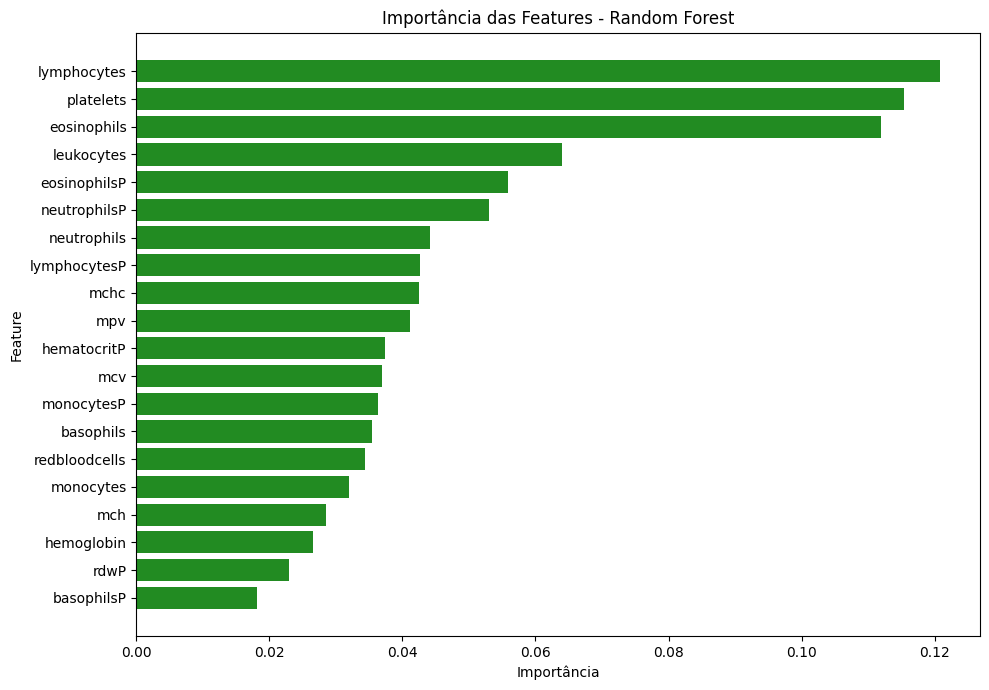

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Importância das features do Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train_exp1.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print('=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===')
print(feature_importance.round(4).to_string(index=False))

plt.figure(figsize=(10, max(6, 0.35 * len(feature_importance))))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='forestgreen')
plt.title('Importância das Features - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Métricas rf_otz_exp1  ===
    Acurácia: 0.8198
    Precisão: 0.8156
    Recall:   0.7583
    F1-Score: 0.7762
    MCC:      0.5711
    AUC:      0.8741


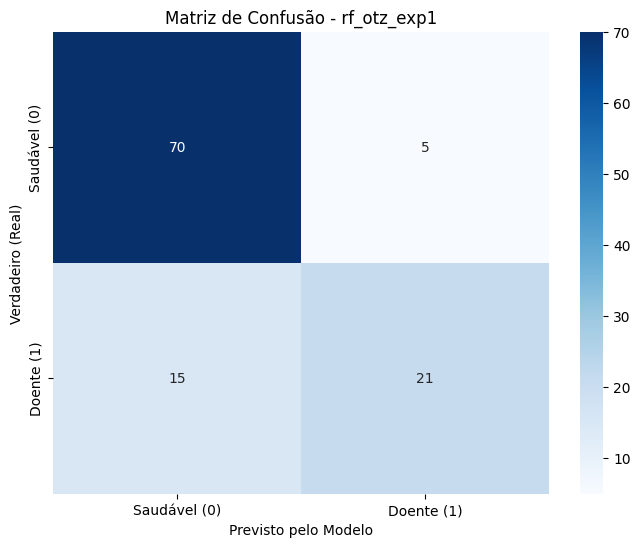

In [27]:
# Avaliar resultados e salvar
y_pred_otz_exp1 = experimento_1.best_model.predict(X_test_exp1)
y_prob_otz_exp1 = experimento_1.best_model.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_otz_exp1, y_prob_otz_exp1, 'rf_otz_exp1')
save_results(y_pred_otz_exp1, y_prob_otz_exp1, 'rf_otz_exp1', caminho)